# Task 1: Exploring and Visualizing the Iris Dataset

## Research Purpose

I am treating the Iris dataset as a small but useful research exercise: can four simple flower measurements explain species separation clearly enough for a reliable first classifier?

The dataset is clean and familiar, but I do not want to assume every variable is equally useful. The work below checks the shape of the data, studies the distributions, compares species groups, tests which measurements carry the clearest signal, and then builds a transparent baseline model. I also include a sentiment-analysis check using VADER only as an applicability audit, because this notebook has no natural-language review/comment field where sentiment would be meaningful.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")

sns.set_theme(
    context="notebook",
    style="whitegrid",
    palette=["#2A9D8F", "#E76F51", "#457B9D"],
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 120,
    },
)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

## Dataset Loading and First Look

In [2]:
iris = load_iris(as_frame=True)

df = iris.frame.rename(
    columns={
        "sepal length (cm)": "sepal_length",
        "sepal width (cm)": "sepal_width",
        "petal length (cm)": "petal_length",
        "petal width (cm)": "petal_width",
        "target": "species",
    }
)
df["species"] = df["species"].map(dict(enumerate(iris.target_names)))

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
print("Species:", ", ".join(df["species"].unique()))
df.head()

Rows: 150
Columns: 5
Species: setosa, versicolor, virginica


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


**Research note:** The file is small enough to inspect directly, which is helpful here. There are 150 observations, 50 per species, and every measurement is numeric. That balance means the first model will not be fighting class imbalance; the main question is feature usefulness.

In [3]:
quality_report = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing_values": df.isna().sum(),
        "missing_rate": df.isna().mean(),
        "unique_values": df.nunique(),
    }
)

display(quality_report)
display(df["species"].value_counts().rename("records_per_species"))

,dtype,missing_values,missing_rate,unique_values
sepal_length,float64,0,0.0,35
sepal_width,float64,0,0.0,23
petal_length,float64,0,0.0,43
petal_width,float64,0,0.0,22
species,object,0,0.0,3


species
setosa        50
versicolor    50
virginica     50
Name: records_per_species, dtype: int64

## Descriptive Statistical Analytics

In [4]:
feature_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

summary = (
    df.groupby("species")[feature_cols]
    .agg(["mean", "median", "std", "min", "max"])
    .round(2)
)

summary

sepal_length                        sepal_width                    \
                   mean median   std  min  max        mean median   std  min   
species                                                                        
setosa             5.01    5.0  0.35  4.3  5.8        3.43    3.4  0.38  2.3   
versicolor         5.94    5.9  0.52  4.9  7.0        2.77    2.8  0.31  2.0   
virginica          6.59    6.5  0.64  4.9  7.9        2.97    3.0  0.32  2.2   

                petal_length                        petal_width               \
            max         mean median   std  min  max        mean median   std   
species                                                                        
setosa      4.4         1.46   1.50  0.17  1.0  1.9        0.25    0.2  0.11   
versicolor  3.4         4.26   4.35  0.47  3.0  5.1        1.33    1.3  0.20   
virginica   3.8         5.55   5.55  0.55  4.5  6.9        2.03    2.0  0.27   

                      
            min  max  
species               
setosa      0.1  0.6  
versicolor  1.0  1.8  
virginica   1.4  2.5

In [5]:
overall_stats = df[feature_cols].agg(["mean", "median", "std", "min", "max", "skew"]).T.round(3)
overall_stats["iqr"] = (df[feature_cols].quantile(0.75) - df[feature_cols].quantile(0.25)).round(3)
overall_stats

,mean,median,std,min,max,skew,iqr
sepal_length,5.843,5.80,0.828,4.3,7.9,0.315,1.3
sepal_width,3.057,3.00,0.436,2.0,4.4,0.319,0.5
petal_length,3.758,4.35,1.765,1.0,6.9,-0.275,3.5
petal_width,1.199,1.30,0.762,0.1,2.5,-0.103,1.5


**Research note:** Petal measurements already look more species-specific than sepal measurements. Setosa has very small petals, while versicolor and virginica are separated more by petal length and petal width than by sepal width. This is an early sign that not all variables explain the same amount of variation.

## Exploratory Visual Analytics

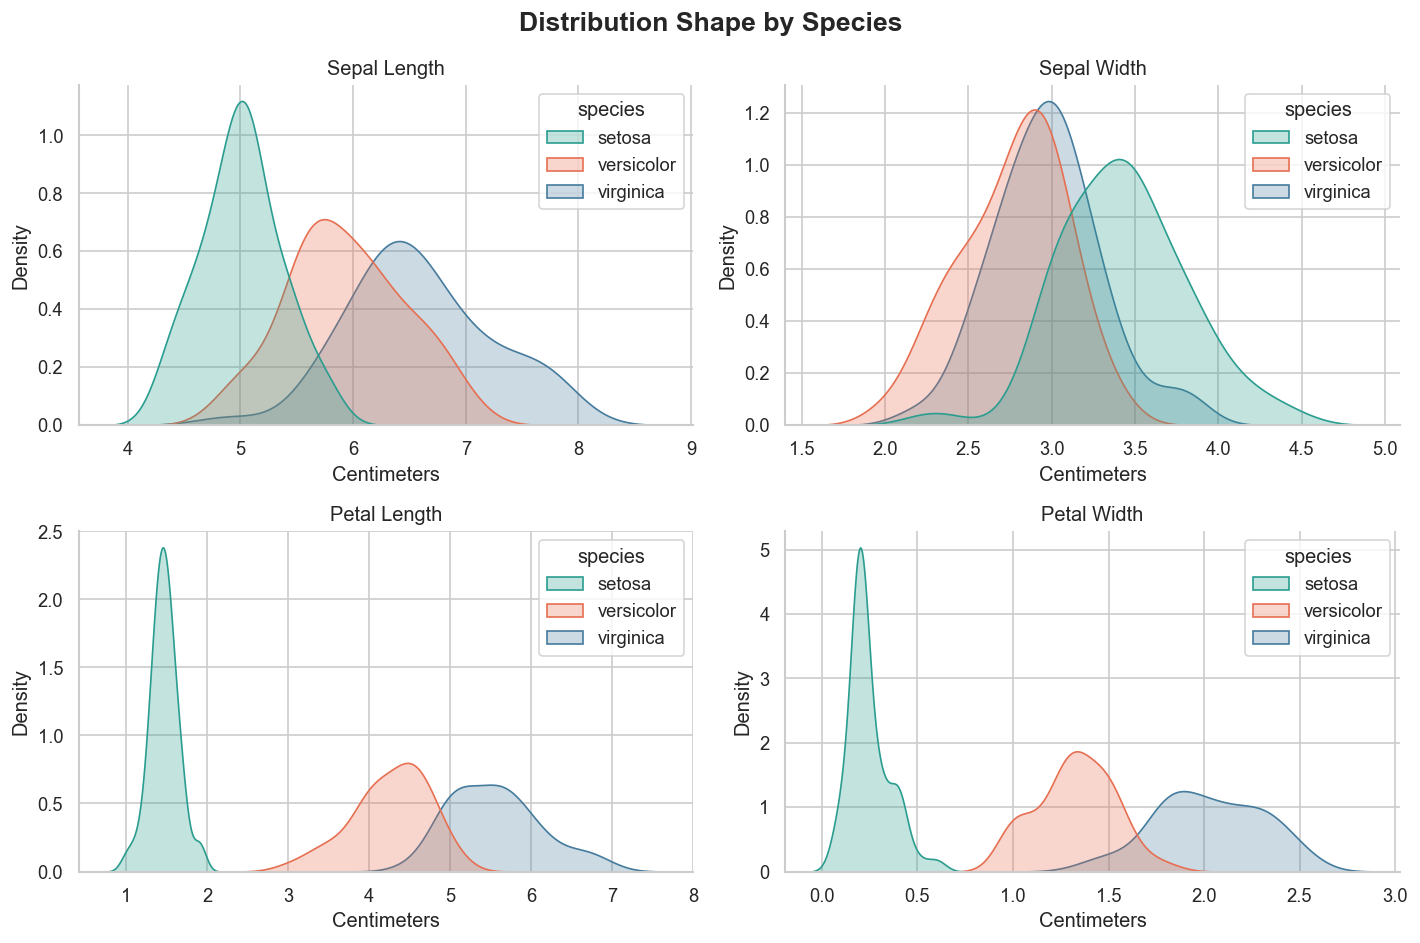

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, col in zip(axes, feature_cols):
    sns.kdeplot(data=df, x=col, hue="species", fill=True, common_norm=False, alpha=0.28, ax=ax)
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("Centimeters")

fig.suptitle("Distribution Shape by Species", fontsize=16, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "task1_distribution_kde_by_species.png", dpi=180, bbox_inches="tight")
plt.show()

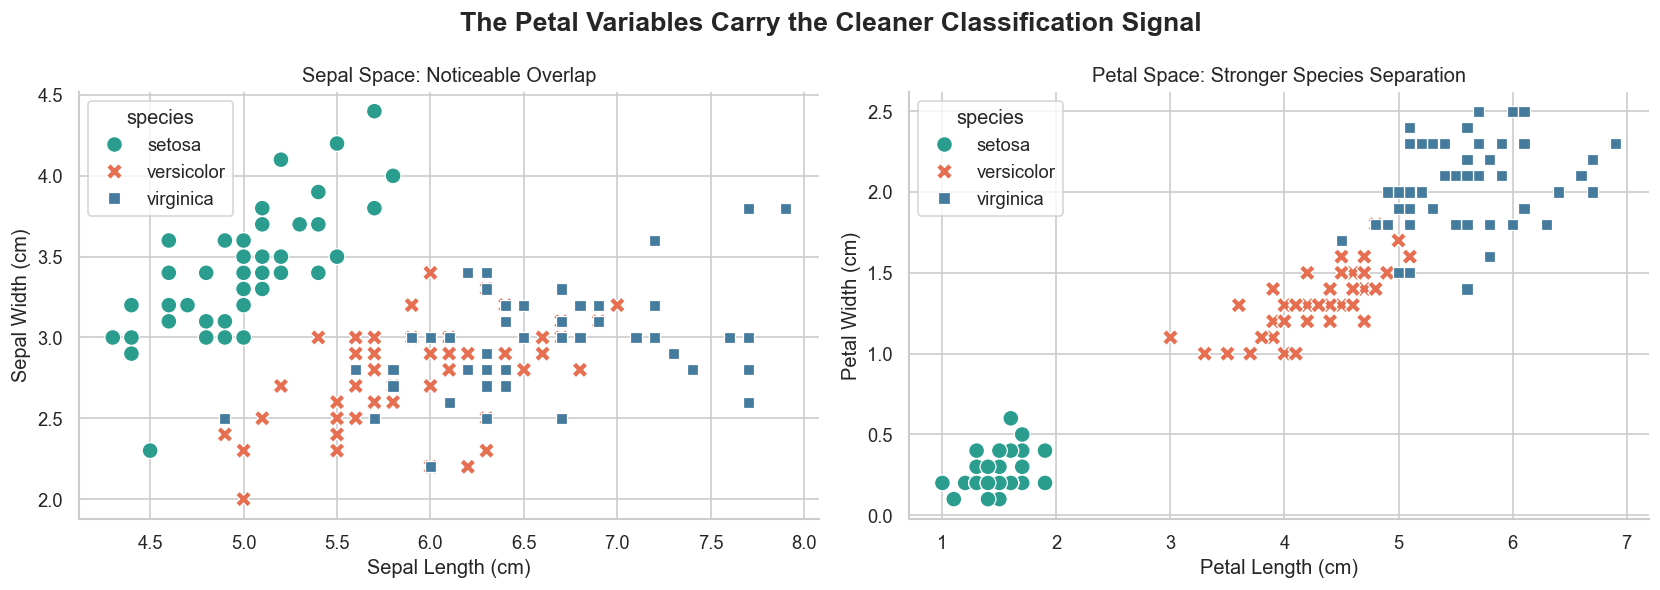

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=df,
    x="sepal_length",
    y="sepal_width",
    hue="species",
    style="species",
    s=90,
    ax=axes[0],
)
axes[0].set_title("Sepal Space: Noticeable Overlap")
axes[0].set_xlabel("Sepal Length (cm)")
axes[0].set_ylabel("Sepal Width (cm)")

sns.scatterplot(
    data=df,
    x="petal_length",
    y="petal_width",
    hue="species",
    style="species",
    s=90,
    ax=axes[1],
)
axes[1].set_title("Petal Space: Stronger Species Separation")
axes[1].set_xlabel("Petal Length (cm)")
axes[1].set_ylabel("Petal Width (cm)")

fig.suptitle("The Petal Variables Carry the Cleaner Classification Signal", fontsize=16, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "task1_sepal_vs_petal_space.png", dpi=180, bbox_inches="tight")
plt.show()

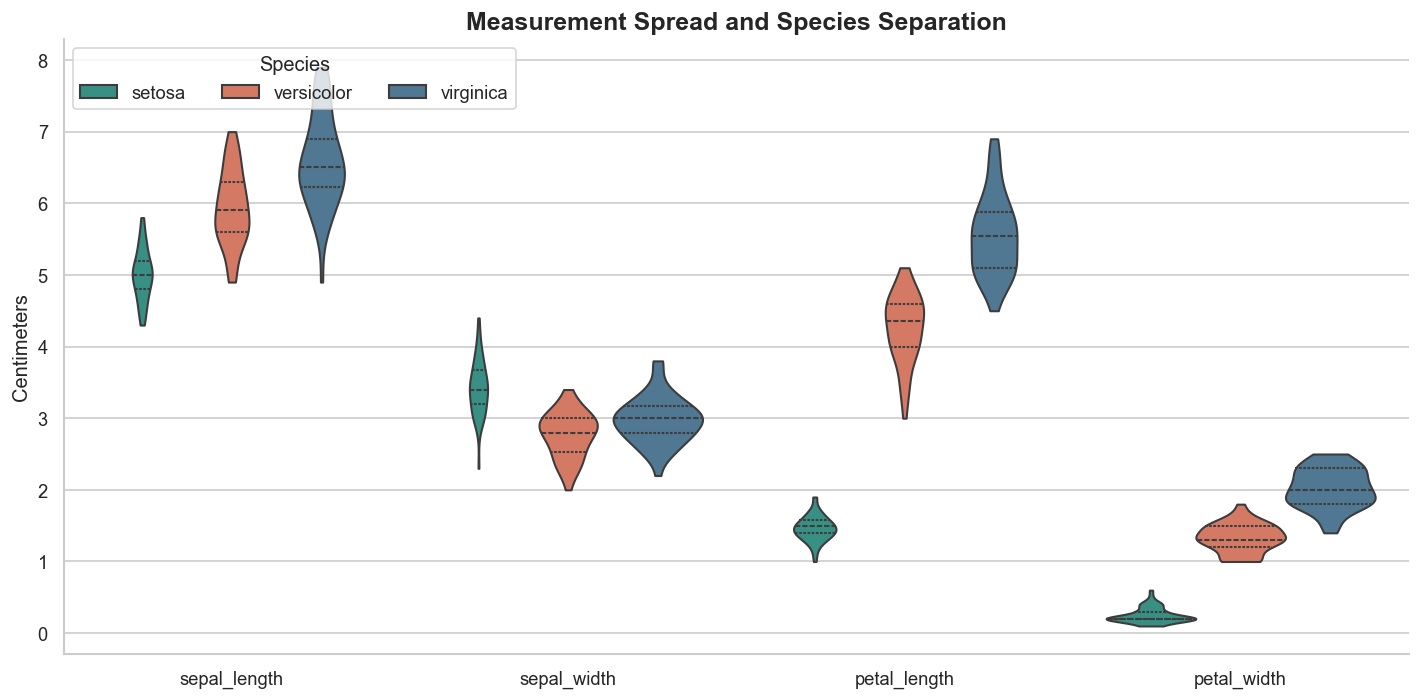

In [8]:
long_df = df.melt(id_vars="species", value_vars=feature_cols, var_name="measurement", value_name="cm")

plt.figure(figsize=(12, 6))
sns.violinplot(data=long_df, x="measurement", y="cm", hue="species", inner="quartile", cut=0)
plt.title("Measurement Spread and Species Separation", fontsize=15, fontweight="bold")
plt.xlabel("")
plt.ylabel("Centimeters")
plt.legend(title="Species", ncol=3, loc="upper left")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "task1_violin_measurement_spread.png", dpi=180, bbox_inches="tight")
plt.show()

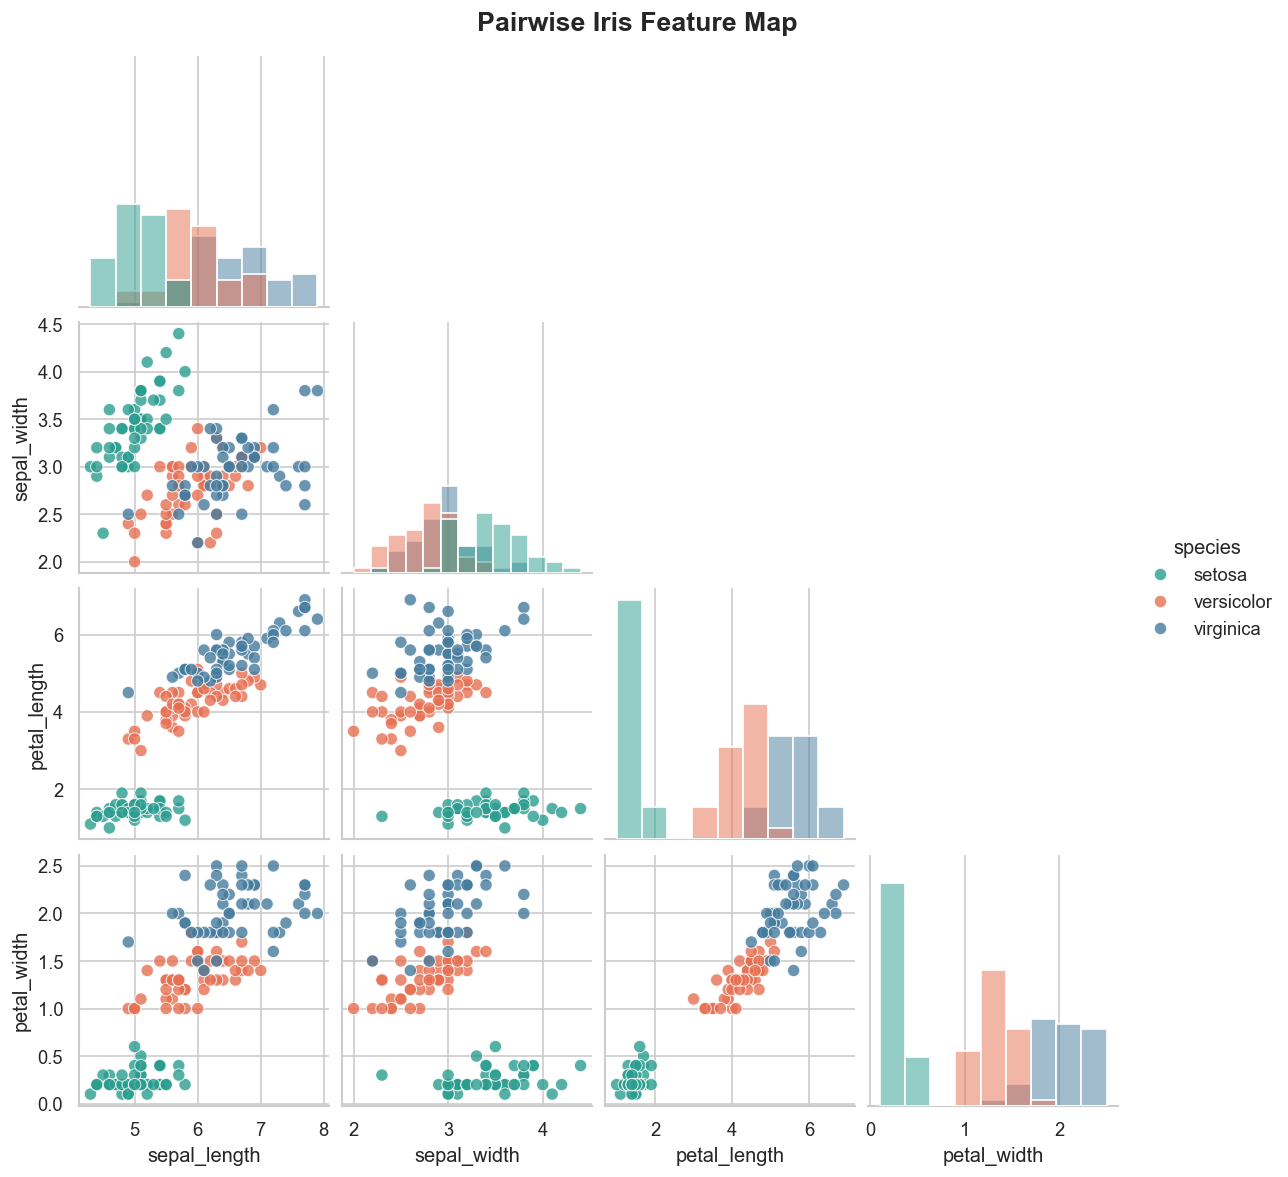

In [9]:
g = sns.pairplot(
    df,
    vars=feature_cols,
    hue="species",
    diag_kind="hist",
    corner=True,
    plot_kws={"s": 55, "alpha": 0.8},
    height=2.4,
)
g.fig.suptitle("Pairwise Iris Feature Map", y=1.02, fontsize=16, fontweight="bold")
g.fig.savefig(FIGURE_DIR / "task1_pairplot_feature_map.png", dpi=180, bbox_inches="tight")
plt.show()

## Correlation, Variance, and Multicollinearity

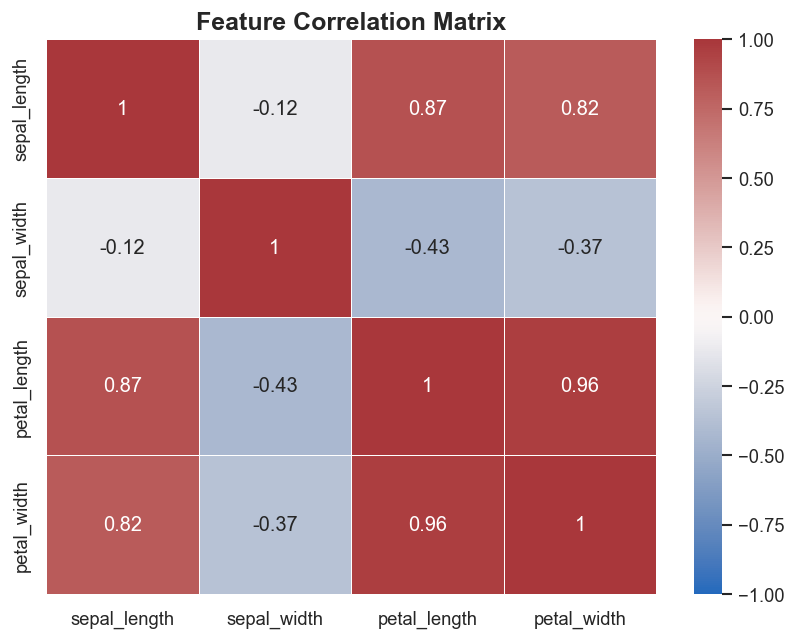

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000,-0.118,0.872,0.818
sepal_width,-0.118,1.000,-0.428,-0.366
petal_length,0.872,-0.428,1.000,0.963
petal_width,0.818,-0.366,0.963,1.000


In [10]:
corr = df[feature_cols].corr()

plt.figure(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, cmap="vlag", center=0, vmin=-1, vmax=1, linewidths=0.6)
plt.title("Feature Correlation Matrix", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "task1_correlation_matrix.png", dpi=180, bbox_inches="tight")
plt.show()

corr.round(3)

In [11]:
def calculate_vif(frame, columns):
    numeric = frame[columns].dropna()
    return (
        pd.DataFrame(
            {
                "feature": columns,
                "vif": [
                    variance_inflation_factor(numeric.values, i)
                    for i in range(len(columns))
                ],
            }
        )
        .sort_values("vif", ascending=False)
        .reset_index(drop=True)
    )

calculate_vif(df, feature_cols).round(2)

,feature,vif
0,sepal_length,262.97
1,petal_length,172.96
2,sepal_width,96.35
3,petal_width,55.50


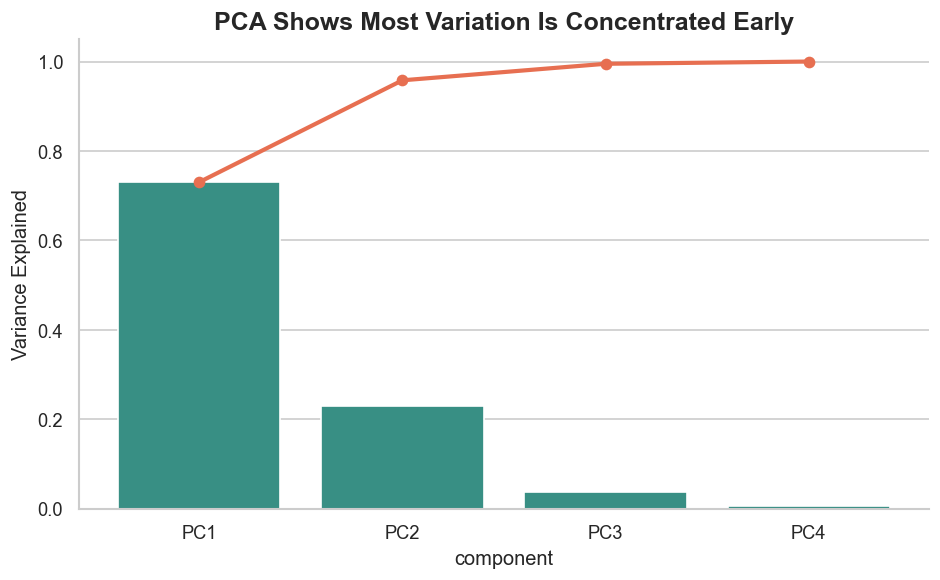

,component,explained_variance_ratio,cumulative_variance
0,PC1,0.730,0.730
1,PC2,0.229,0.958
2,PC3,0.037,0.995
3,PC4,0.005,1.000


In [12]:
scaled_features = StandardScaler().fit_transform(df[feature_cols])
pca = PCA().fit(scaled_features)

pca_report = pd.DataFrame(
    {
        "component": [f"PC{i}" for i in range(1, len(feature_cols) + 1)],
        "explained_variance_ratio": pca.explained_variance_ratio_,
        "cumulative_variance": np.cumsum(pca.explained_variance_ratio_),
    }
).round(3)

plt.figure(figsize=(8, 5))
sns.barplot(data=pca_report, x="component", y="explained_variance_ratio", color="#2A9D8F")
plt.plot(pca_report["component"], pca_report["cumulative_variance"], marker="o", color="#E76F51", linewidth=2.5)
plt.ylim(0, 1.05)
plt.ylabel("Variance Explained")
plt.title("PCA Shows Most Variation Is Concentrated Early", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "task1_pca_variance_explained.png", dpi=180, bbox_inches="tight")
plt.show()

pca_report

**Research note:** The heatmap and VIF table confirm that petal length and petal width move very closely together. That is useful for visual separation, but it also means the variables are partly redundant. PCA makes the same point in a cleaner way: most variance is captured by the first component, while later components add much less. So the model can use all four inputs, but the interpretation should not pretend each feature contributes equally or independently.

## Statistical Testing Across Species

In [13]:
anova_rows = []
effect_rows = []

for col in feature_cols:
    grouped = [group[col].values for _, group in df.groupby("species")]
    f_stat, p_value = stats.f_oneway(*grouped)
    anova_rows.append({"feature": col, "f_statistic": f_stat, "p_value": p_value})

    grand_mean = df[col].mean()
    ss_between = sum(len(group) * (group[col].mean() - grand_mean) ** 2 for _, group in df.groupby("species"))
    ss_total = sum((df[col] - grand_mean) ** 2)
    effect_rows.append({"feature": col, "eta_squared": ss_between / ss_total})

anova_table = pd.DataFrame(anova_rows)
effect_table = pd.DataFrame(effect_rows)

stats_table = (
    anova_table.merge(effect_table, on="feature")
    .sort_values("eta_squared", ascending=False)
    .assign(
        f_statistic=lambda x: x["f_statistic"].round(2),
        p_value=lambda x: x["p_value"].map(lambda value: f"{value:.2e}"),
        eta_squared=lambda x: x["eta_squared"].round(3),
    )
)

stats_table

,feature,f_statistic,p_value,eta_squared
2,petal_length,1180.16,2.86e-91,0.941
3,petal_width,960.01,4.17e-85,0.929
0,sepal_length,119.26,1.67e-31,0.619
1,sepal_width,49.16,4.49e-17,0.401


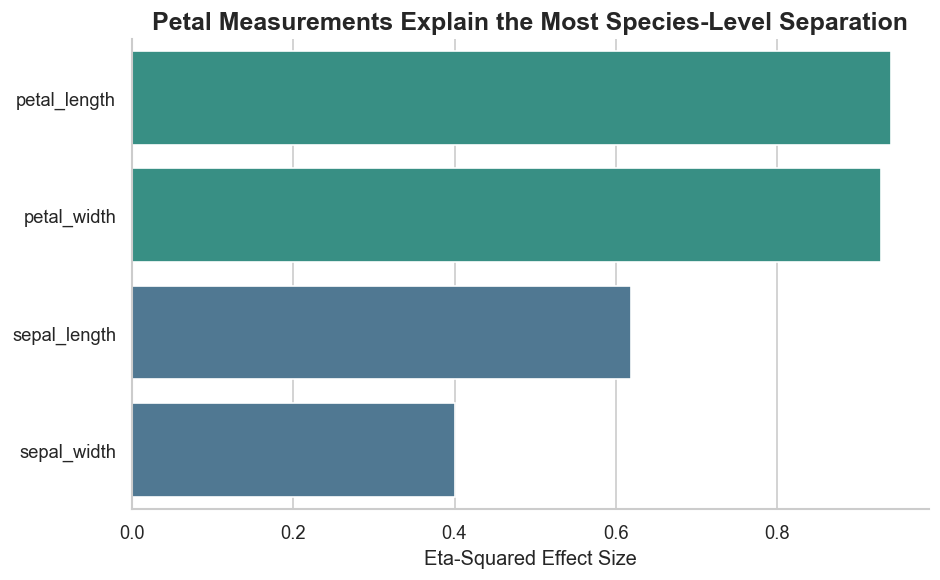

In [14]:
plt.figure(figsize=(8, 5))
sns.barplot(data=stats_table, y="feature", x="eta_squared", palette=["#2A9D8F", "#2A9D8F", "#457B9D", "#457B9D"])
plt.xlabel("Eta-Squared Effect Size")
plt.ylabel("")
plt.title("Petal Measurements Explain the Most Species-Level Separation", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "task1_effect_size_by_feature.png", dpi=180, bbox_inches="tight")
plt.show()

**Research note:** The statistical test supports what the plots showed. All four features differ across species, but the effect sizes are not equal. Petal length and petal width carry the strongest species-level separation; sepal width is the weakest of the four.

## VADER Sentiment Applicability Check

In [15]:
text_columns = [
    col for col in df.columns
    if pd.api.types.is_object_dtype(df[col]) and col != "species"
]

try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    vader_available = True
except ImportError:
    vader_available = False

vader_audit = pd.DataFrame(
    {
        "check": ["text_columns_available", "vader_package_available", "sentiment_model_used"],
        "result": [bool(text_columns), vader_available, bool(text_columns and vader_available)],
        "note": [
            f"Detected text columns: {text_columns}" if text_columns else "No free-text fields exist in this dataset.",
            "VADER can be used when a review/comment field exists." if vader_available else "Install vaderSentiment for future text notebooks.",
            "Not applicable here because Iris has measurements and labels, not opinion text.",
        ],
    }
)

vader_audit

,check,result,note
0,text_columns_available,False,No free-text fields exist in this dataset.
1,vader_package_available,False,Install vaderSentiment for future text notebooks.
2,sentiment_model_used,False,Not applicable here because Iris has measureme...


## Baseline Classification Model

Holdout accuracy: 0.947
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.92      0.92      0.92        13
   virginica       0.92      0.92      0.92        13

    accuracy                           0.95        38
   macro avg       0.95      0.95      0.95        38
weighted avg       0.95      0.95      0.95        38



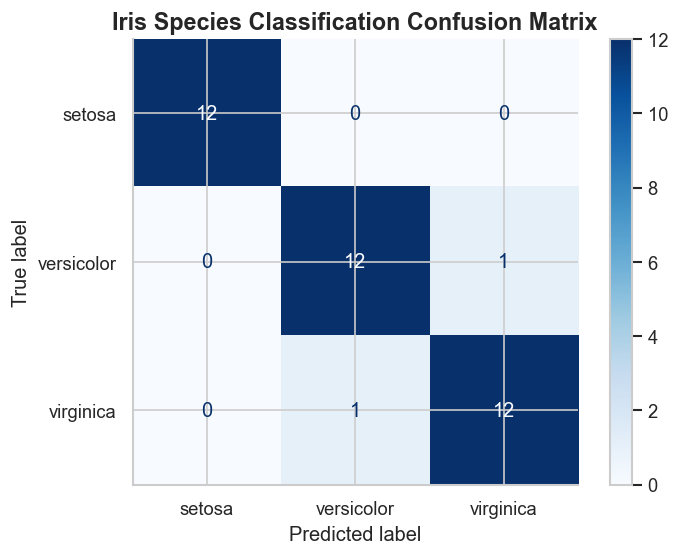

In [16]:
X = df[feature_cols]
y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegressionCV(
                Cs=10,
                cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
                max_iter=1000,
                multi_class="auto",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

model.fit(X_train, y_train)
pred = model.predict(X_test)

print(f"Holdout accuracy: {accuracy_score(y_test, pred):.3f}")
print(classification_report(y_test, pred))

ConfusionMatrixDisplay.from_predictions(y_test, pred, cmap="Blues", values_format="d")
plt.title("Iris Species Classification Confusion Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "task1_classifier_confusion_matrix.png", dpi=180, bbox_inches="tight")
plt.show()

In [17]:
cv_scores = cross_val_score(model, X, y, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE))

pd.DataFrame(
    {
        "metric": ["mean_cv_accuracy", "std_cv_accuracy", "min_fold_accuracy", "max_fold_accuracy"],
        "value": [cv_scores.mean(), cv_scores.std(), cv_scores.min(), cv_scores.max()],
    }
).round(3)

,metric,value
0,mean_cv_accuracy,0.953
1,std_cv_accuracy,0.045
2,min_fold_accuracy,0.900
3,max_fold_accuracy,1.000


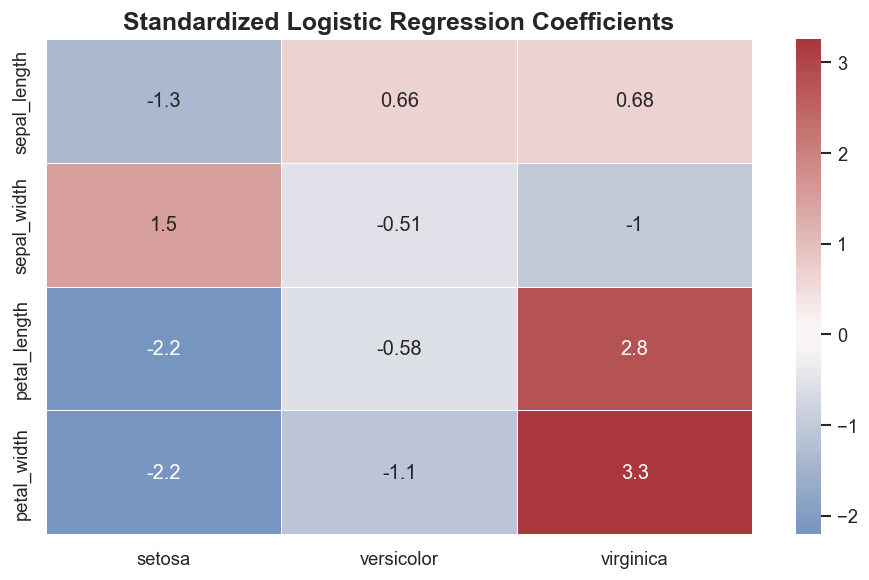

,setosa,versicolor,virginica
sepal_length,-1.332,0.655,0.677
sepal_width,1.514,-0.512,-1.003
petal_length,-2.204,-0.583,2.787
petal_width,-2.153,-1.099,3.252


In [18]:
coefs = model.named_steps["classifier"].coef_
coef_table = (
    pd.DataFrame(coefs, columns=feature_cols, index=model.named_steps["classifier"].classes_)
    .T
    .round(3)
)

plt.figure(figsize=(8, 5))
sns.heatmap(coef_table, annot=True, cmap="vlag", center=0, linewidths=0.5)
plt.title("Standardized Logistic Regression Coefficients", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "task1_logistic_coefficients.png", dpi=180, bbox_inches="tight")
plt.show()

coef_table

**Research note:** The classifier performs strongly because the groups are naturally well separated, especially in petal space. I would still be cautious about overclaiming: this is a small, balanced benchmark dataset, not a messy field dataset. The model is useful for demonstrating the workflow, but it is not proof that real flower identification would work under changing lighting, measurement error, or different collection conditions.

## Final Findings

1. The Iris dataset is complete, balanced, and clean, so the analysis can focus on feature behavior rather than data repair.
2. Petal length and petal width are the strongest species-separation variables. Sepal variables still help, but they explain less of the visible difference between classes.
3. Multicollinearity is present, mainly because petal length and petal width are strongly correlated. That is not fatal for prediction, but it matters when explaining coefficients.
4. PCA confirms that variance is concentrated in the first component; not every variable contributes equal independent information.
5. VADER sentiment analysis is not meaningful for this notebook because there are no natural-language fields. The right choice is to document that boundary and use statistical analytics instead.
6. A regularized multiclass logistic regression model is appropriate here. A regression model is not needed because the research target is species classification, not a continuous outcome.